In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_excel("../data/raw/Customers.xlsx", sheet_name=1)
accounts = pd.read_excel("../data/raw/Banking_Account.xlsx", sheet_name=1)
loans = pd.read_excel("../data/raw/Loan_Data.xlsx", sheet_name=1)
transactions = pd.read_excel("../data/raw/transaction_data.xlsx")
branches = pd.read_excel("../data/raw/Branch.xlsx", sheet_name=1)

customer table cleaning

In [2]:
print(customers.head())
print(customers.shape)
print(customers.info())
print(customers.describe())

  Customer_ID First_Name Last_Name  Gender  Age Marital_Status  \
0      C00001      Karan    Saxena    Male   41         Single   
1      C00002     Monika    Saxena  Female   38         Single   
2      C00003   Sangeeta    Pillai  Female   62        Married   
3      C00004      Kriti    Pillai  Female   55        Married   
4      C00005     Aditya     Kumar    Male   44        Married   

       Occupation  Annual_Income     City        State Customer_Since  \
0      Consultant        1200000    Thane  Maharashtra     2016-12-22   
1        Business        1750000    Thane  Maharashtra     2021-11-17   
2    HR Executive         850000   Jaipur    Rajasthan     2017-04-08   
3          Doctor        1740000  Kolkata  West Bengal     2018-01-20   
4  Civil Engineer         770000   Mysuru    Karnataka     2019-07-06   

  Customer_Segment  
0         Platinum  
1         Platinum  
2             Gold  
3         Platinum  
4             Gold  
(75000, 12)
<class 'pandas.DataFrame'>

In [3]:
customers["Customer_Since"]=pd.to_datetime(customers["Customer_Since"])

customers.isnull().sum()
customers.duplicated().sum()
customers["Customer_ID"].duplicated().sum()

customers["Gender"].unique()
customers["Marital_Status"].unique()
customers["Customer_Segment"].unique()
customers["Occupation"].unique()
customers["State"].unique()
customers["Age"].describe()
customers["Annual_Income"].describe()
customers["Gender"].value_counts()
customers["Customer_Segment"].value_counts()
customers["Marital_Status"].value_counts()

Marital_Status
Married    48653
Single     26347
Name: count, dtype: int64

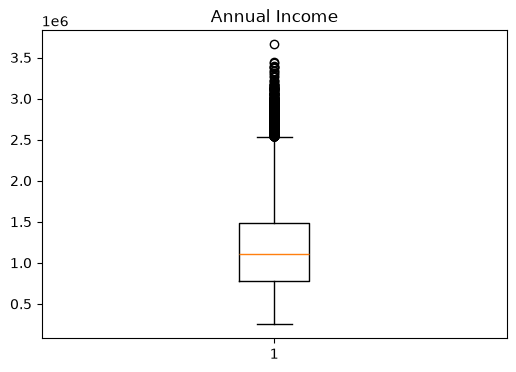

In [4]:
plt.figure(figsize=(6,4))
plt.boxplot(customers["Annual_Income"])
plt.title("Annual Income")
plt.show()

customers["Customer_Tenure"] = (
    pd.Timestamp.today().year - customers["Customer_Since"].dt.year
)

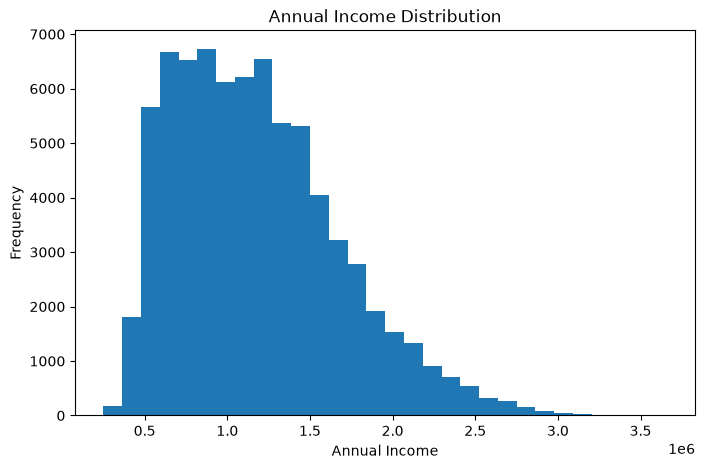

In [5]:
plt.figure(figsize=(8,5))
plt.hist(customers["Annual_Income"], bins=30)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.show()

In [6]:
customers.columns = (customers.columns.str.strip().str.lower().str.replace(" ", "_") )
customers.to_csv("../data/clean/customers_clean.csv", index=False)

branch table cleaning

In [7]:
branches.head()
branches.shape
branches.info()
branches.describe()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Branch ID    101 non-null    str    
 1   Branch Name  100 non-null    str    
 2   City         100 non-null    str    
 3   State        100 non-null    str    
 4   Region       101 non-null    str    
 5   Employees    100 non-null    float64
dtypes: float64(1), str(5)
memory usage: 4.9 KB


,Employees
count,100.000000
mean,122.350000
std,54.807722
min,32.000000
25%,76.000000
50%,118.000000
75%,167.250000
max,218.000000


In [8]:
branches.isnull().sum()
branches[branches.isnull().any(axis=1)]
branches = branches[branches["Branch ID"] != "Total"]
branches.isnull().sum()
branches["Employees"]=branches["Employees"].astype("int64")
branches.duplicated().sum()
branches["Branch ID"].duplicated().sum()


np.int64(0)

In [9]:
branches["Branch Name"].unique()
branches["City"].unique()
branches["State"].unique()
branches["Region"].unique()

<StringArray>
['East', 'South', 'North', 'West', 'Central']
Length: 5, dtype: str

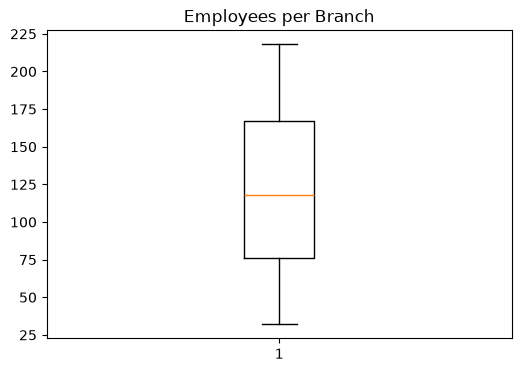

In [10]:
plt.figure(figsize=(6,4))
plt.boxplot(branches["Employees"])
plt.title("Employees per Branch")
plt.show()

In [11]:
branches.columns = (branches.columns.str.strip().str.lower().str.replace(" ", "_") )
branches.to_csv("../data/clean/branches_clean.csv", index=False)

account cleaning

In [12]:
accounts.head()
accounts.shape
accounts.info()
accounts.describe()

<class 'pandas.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Account_ID      85000 non-null  str    
 1   Customer_ID     85000 non-null  str    
 2   Account_Type    85000 non-null  str    
 3   Balance         85000 non-null  float64
 4   Branch_ID       85000 non-null  str    
 5   Account_Status  85000 non-null  str    
 6   Open_Date       85000 non-null  str    
dtypes: float64(1), str(6)
memory usage: 4.5 MB


,Balance
count,85000.000000
mean,28337.445339
std,54173.066112
min,-199901.670000
25%,4256.402500
50%,22647.565000
75%,47765.985000
max,249954.110000


In [13]:
accounts["Open_Date"]=pd.to_datetime(accounts["Open_Date"])

accounts[accounts["Balance"] < 0]["Account_Type"].value_counts()

accounts.isnull().sum()
accounts.duplicated().sum()
accounts["Account_ID"].duplicated().sum()

accounts[~accounts["Customer_ID"].isin(customers["customer_id"])]

accounts[~accounts["Branch_ID"].isin(branches["branch_id"])]

,Account_ID,Customer_ID,Account_Type,Balance,Branch_ID,Account_Status,Open_Date


In [14]:
accounts["Account_Type"].unique()
accounts["Account_Status"].value_counts()
accounts[accounts["Balance"] < 0]["Account_Type"].value_counts()
accounts[
    (accounts["Balance"] < 0) &
    (accounts["Account_Type"].isin(["Savings", "Checking"]))]

,Account_ID,Customer_ID,Account_Type,Balance,Branch_ID,Account_Status,Open_Date


In [15]:
accounts.columns = (accounts.columns.str.strip().str.lower().str.replace(" ", "_") )
accounts.to_csv("../data/clean/accounts_clean.csv", index=False)

loan data cleaning

In [16]:
loans.head()
loans.shape
loans.info()
loans.describe()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            30000 non-null  str    
 1   Customer_ID        30000 non-null  str    
 2   Loan_Type          30000 non-null  str    
 3   Loan_Amount        30000 non-null  int64  
 4   Interest_Rate      30000 non-null  float64
 5   EMI                30000 non-null  int64  
 6   Credit_Score       30000 non-null  int64  
 7   Loan_Status        30000 non-null  str    
 8   Default_Flag       30000 non-null  str    
 9   Remaining_Balance  30000 non-null  int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 2.3 MB


,Loan_Amount,Interest_Rate,EMI,Credit_Score,Remaining_Balance
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,138152.533333,0.092689,1749.124233,688.961133,48765.193333
std,147252.286144,0.022650,1557.257144,82.971034,80432.146928
min,3000.000000,0.045000,62.000000,324.000000,0.000000
25%,27000.000000,0.075475,711.000000,632.000000,0.000000
50%,58000.000000,0.090250,1244.000000,690.000000,13100.000000
75%,225000.000000,0.109700,2449.000000,748.000000,52700.000000
max,500000.000000,0.170400,11936.000000,850.000000,460200.000000


In [17]:
loans.isnull().sum()
loans["Loan_ID"].isnull().sum()
loans.duplicated().sum()
loans[~loans["Customer_ID"].isin(customers["customer_id"])]
loans[
    (loans["Credit_Score"] < 300) |(loans["Credit_Score"] > 850)]

loans[loans["Remaining_Balance"] > loans["Loan_Amount"]]

loans[
    (loans["Loan_Status"] == "Closed") &(loans["Remaining_Balance"] != 0)]

loans[
    (loans["Loan_Status"] == "Active") &(loans["Remaining_Balance"] == 0)]

loans["Default_Flag"].value_counts()
loans["Loan_Status"].value_counts()

Loan_Status
Active       20948
Closed        8600
Defaulted      452
Name: count, dtype: int64

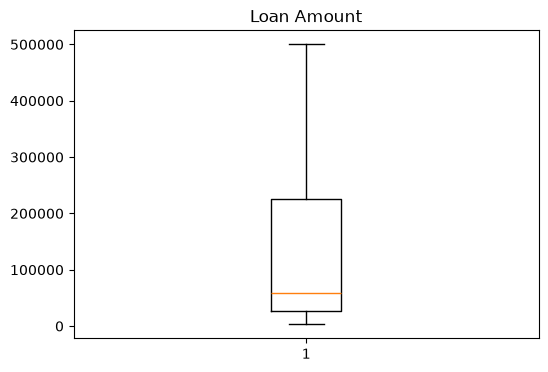

In [18]:
plt.figure(figsize=(6,4))
plt.boxplot(loans["Loan_Amount"])
plt.title("Loan Amount")
plt.show()

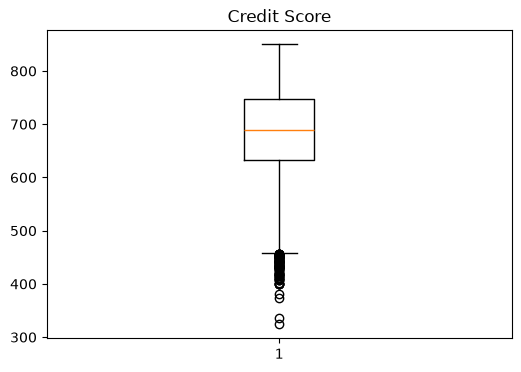

In [19]:
plt.figure(figsize=(6,4))
plt.boxplot(loans["Credit_Score"])
plt.title("Credit Score")
plt.show()

In [20]:
loans.columns = (loans.columns.str.strip().str.lower().str.replace(" ","_"))
loans.to_csv("../data/clean/loans_clean.csv", index=False)

transaction table cleaning

In [21]:
transactions.head()
transactions.shape
transactions.info()
transactions.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Transaction_ID    500000 non-null  str           
 1   Customer_ID       500000 non-null  str           
 2   Account_ID        500000 non-null  str           
 3   Date              500000 non-null  datetime64[us]
 4   Transaction_Type  500000 non-null  str           
 5   Amount            500000 non-null  int64         
 6   Merchant          500000 non-null  str           
 7   Payment_Mode      500000 non-null  str           
 8   Status            500000 non-null  str           
dtypes: datetime64[us](1), int64(1), str(7)
memory usage: 34.3 MB


,Date,Amount
count,500000,500000.000000
mean,2026-04-14 13:22:50.591999,12036.543832
min,2026-01-01 00:00:00,10.000000
25%,2026-02-21 00:00:00,1560.000000
50%,2026-04-15 00:00:00,3096.000000
75%,2026-06-06 00:00:00,4637.000000
max,2026-07-27 00:00:00,99998.000000
std,NaN,23036.009929


In [22]:
transactions.isnull().sum()
transactions.duplicated().sum()
transactions["Transaction_ID"].duplicated().sum()
transactions[~transactions["Customer_ID"].isin(customers["customer_id"])]

transactions[~transactions["Account_ID"].isin(accounts["account_id"])]
transactions["Transaction_Type"].value_counts()
transactions["Payment_Mode"].value_counts()
transactions["Status"].value_counts()

Status
Success    460053
Failed      24930
Pending     15017
Name: count, dtype: int64

In [23]:
transactions["Amount"].describe()
transactions[transactions["Amount"] <= 0]
transactions[
    (transactions["Merchant"] == "Bank Refund") &(transactions["Transaction_Type"] != "Credit")]

,Transaction_ID,Customer_ID,Account_ID,Date,Transaction_Type,Amount,Merchant,Payment_Mode,Status


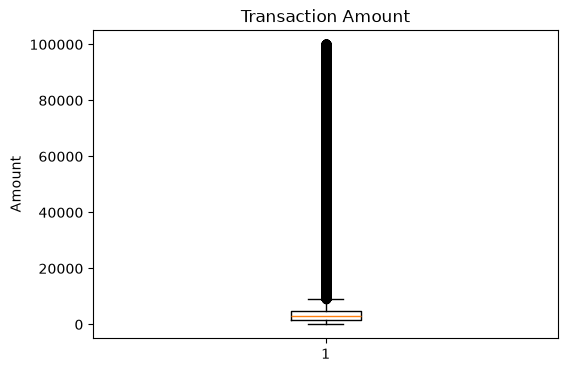

In [24]:
plt.figure(figsize=(6,4))
plt.boxplot(transactions["Amount"])
plt.title("Transaction Amount")
plt.ylabel("Amount")
plt.show()

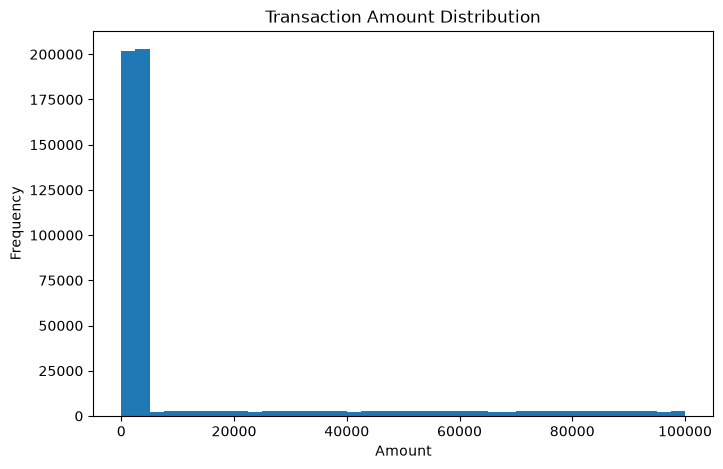

In [25]:
plt.figure(figsize=(8,5))
plt.hist(transactions["Amount"], bins=40)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [26]:
transactions.columns = (transactions.columns.str.strip().str.lower().str.replace(" ","_"))
transactions.to_csv("../data/clean/transactions_clean.csv", index=False)

In [27]:
customers.head(1000).to_csv("../data/sample_dataset/customers_sample.csv", index=False)
accounts.head(1000).to_csv("../data/sample_dataset/accounts_sample.csv", index=False)
loans.head(1000).to_csv("../data/sample_dataset/loans_sample.csv", index=False)
transactions.head(1000).to_csv("../data/sample_dataset/transactions_sample.csv", index=False)
branches.to_csv("../data/sample_dataset/branches_sample.csv", index=False)